### Упражнение 2.5

In [44]:
import math
import numpy as np
import matplotlib.pyplot as plt

Задание 1

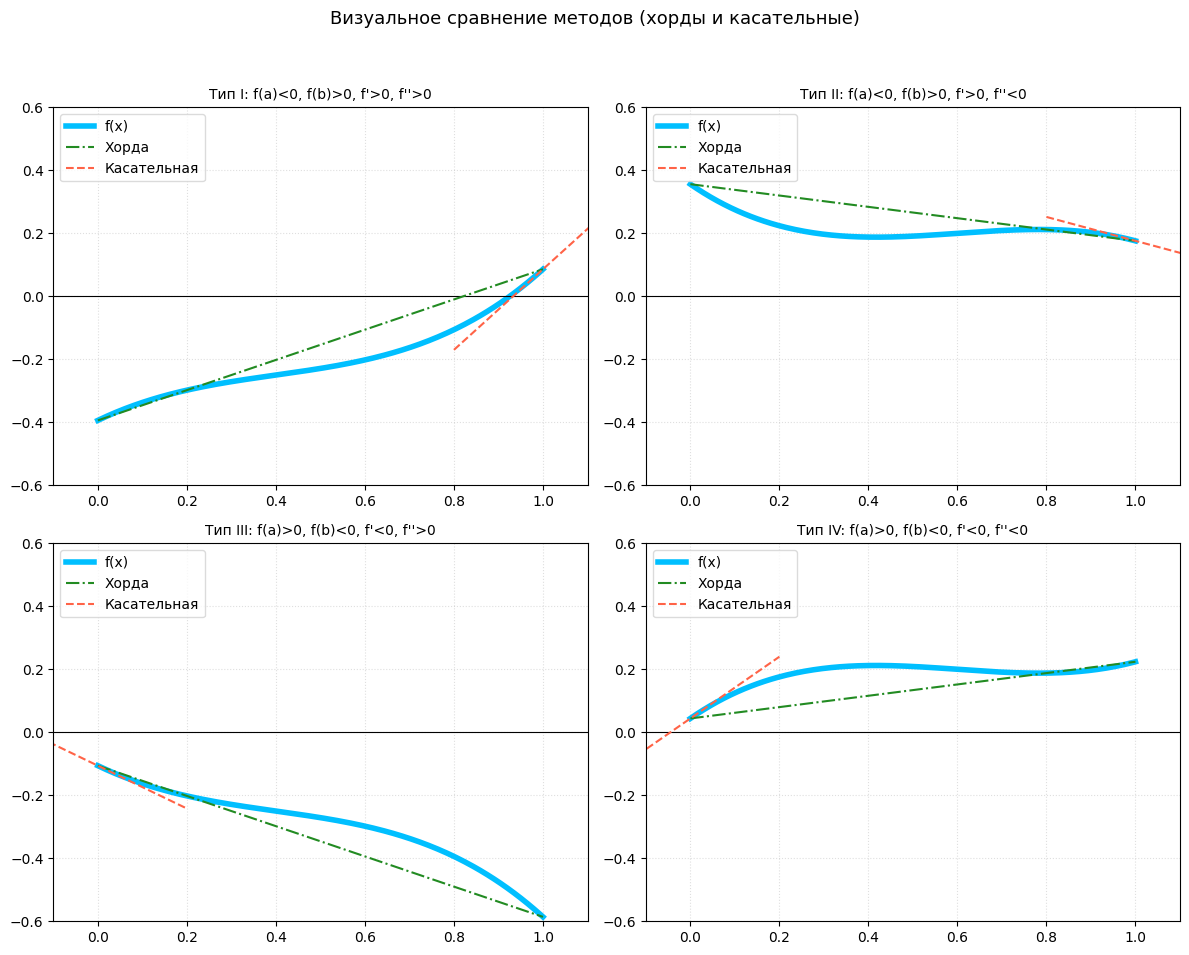

In [45]:
def curve_1(x): return (x - 0.4)**3 + 0.2*(x - 0.4) - 0.25
def curve_2(x): return -((x - 0.6)**3) + 0.1*(x - 0.6) + 0.2
def curve_3(x): return -((x - 0.4)**3) - 0.2*(x - 0.4) - 0.25
def curve_4(x): return (x - 0.6)**3 - 0.1*(x - 0.6) + 0.2

data_sets = [
    (curve_1, "Тип I: f(a)<0, f(b)>0, f'>0, f''>0", 'right'),
    (curve_2, "Тип II: f(a)<0, f(b)>0, f'>0, f''<0", 'right'),
    (curve_3, "Тип III: f(a)>0, f(b)<0, f'<0, f''>0", 'left'),
    (curve_4, "Тип IV: f(a)>0, f(b)<0, f'<0, f''<0", 'left')
]

fig, plots = plt.subplots(2, 2, figsize=(12, 10))
flat_plots = plots.flatten()

for i, (math_func, txt, side) in enumerate(data_sets):
    ax = flat_plots[i]
    x_axis = np.linspace(0, 1, 200)
    
    # Линия f(x) — толстая и голубая, как на скрине
    ax.plot(x_axis, math_func(x_axis), color='#00BFFF', lw=4, label='f(x)')
    ax.axhline(0, color='black', lw=0.8)
    
    # Хорда — зеленая, стиль "штрих-пунктир"
    p1, p2 = 0, 1
    ax.plot([p1, p2], [math_func(p1), math_func(p2)], 
            color='forestgreen', ls='-.', lw=1.5, label='Хорда')
    
    # Касательная — оранжево-красная, стиль "пунктир"
    ref_x = p2 if side == 'right' else p1
    step = 1e-5
    deriv = (math_func(ref_x + step) - math_func(ref_x)) / step
    x_intercept = ref_x - math_func(ref_x) / deriv
    
    t_line_x = np.linspace(ref_x - 0.2, ref_x + 0.2, 10)
    t_line_y = math_func(ref_x) + deriv * (t_line_x - ref_x)
    ax.plot(t_line_x, t_line_y, color='#FF6347', ls='--', lw=1.5, label='Касательная')

    # Оформление легенды в рамке (как на скриншоте)
    ax.legend(loc='upper left', frameon=True, shadow=False, 
              edgecolor='#D3D3D3', facecolor='white', fontsize=10)

    # Настройка сетки и лимитов
    ax.set_title(txt, fontsize=10, loc='center')
    ax.grid(True, ls=':', alpha=0.4)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.6, 0.6)

plt.suptitle('Визуальное сравнение методов (хорды и касательные)', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Задание 2

In [46]:
def func_val(v):
    return v**3 + 3*v**2 - 24*v + 1
def deriv_1(v):
    return 3*v**2 + 6*v - 24
def deriv_2(v):
    return 6*v + 6

def run_solver(low, high, precision=1e-6):
    # Измененный заголовок
    print("комбинированый метод")
    print(f"область: [{low}, {high}] | eps = {precision}")
    print("=" * 56)
    print(f"{'№':<4} | {'метод хорд':^14} | {'метод касат.':^14} | {'delta':^10}")
    print("-" * 56)
    a, b = low, high
    
    for k in range(1, 21):
        
        fa, fb = func_val(a), func_val(b)
        x_h = a - fa * (b - a) / (fb - fa)
        
        if fa * deriv_2(a) > 0:
            x_k = a - fa / deriv_1(a)
        else:
            x_k = b - fb / deriv_1(b)
            
        diff = abs(x_h - x_k)

        print(f"{k:<4d} | {x_h:14.8f} | {x_k:14.8f} | {diff:10.2e}")
        
        if diff < precision:
            root_final = (x_h + x_k) / 2
            print("=" * 56)
            print(f"итоговое значение: {root_final:.8f}")
            print(f"значение F(x) в корне: {func_val(root_final):.2e}")
            return root_final

        a, b = sorted([x_h, x_k])

if __name__ == "__main__":
    run_solver(0, 1)

комбинированый метод
область: [0, 1] | eps = 1e-06
№    |   метод хорд   |  метод касат.  |   delta   
--------------------------------------------------------
1    |     0.05000000 |     0.04166667 |   8.33e-03
2    |     0.04188930 |     0.04188906 |   2.45e-07
итоговое значение: 0.04188918
значение F(x) в корне: -2.75e-06
